# 03/07 — Broader signatures, beyond PIG

PIG is microglia-centric. BRICHOS may also modulate astrocyte reactivity, oligodendrocyte stress, barrier integrity, neuronal / synaptic biology, and chaperone networks. This notebook:

1. **Multi-signature heatmap.** For every signature in `utils.gene_sets.SIGNATURE_REGISTRY`, compute per-region rescue concordance + median signed LFC. Heatmap of regions x signatures shows where BRICHOS hits which biology.
2. **Discovery.** Per region, top BRI-vs-PBS DEGs *outside* PIG. Annotates each with literature-set membership so novel modulators stand out.
3. **Pathway enrichment** (optional). GSEA via `gseapy` if installed.

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

ROOT = Path.cwd().resolve()
while not (ROOT / 'utils').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('could not locate project root')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# regional-annotation h5ad lives on the processing volume
BASEDIR = Path('/Volumes/processing2/ST_BRICHOS/data')
H5AD_ORIENTED = BASEDIR / 'ST_BRICHOS_region_subcluster_oriented.h5ad'
H5AD_BASE     = BASEDIR / 'ST_BRICHOS_region_subcluster.h5ad'
H5AD = H5AD_ORIENTED if H5AD_ORIENTED.exists() else H5AD_BASE
COUNT_LAYER = 'counts'   # raw integer counts live here, not in .X

TBL = ROOT / 'results' / 'tables' / 'attenuation'
TBL.mkdir(parents=True, exist_ok=True)
FIG = ROOT / 'results' / 'figures' / 'manuscript'
FIG.mkdir(parents=True, exist_ok=True)

SAMPLE_KEY    = 'sample_id'           # change to 'library_id' if obs uses that
REGION_KEY    = 're_annotation_regions'   # adjust to your obs column for regions
TREATMENT_KEY = 'treatment'
print('h5ad        :', H5AD)
print('count layer :', COUNT_LAYER)


h5ad        : /Volumes/processing2/ST_BRICHOS/data/ST_BRICHOS_region_subcluster.h5ad
count layer : counts


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
from utils.attenuation import pseudobulk_lfc, signed_rescue
from utils.gene_sets import (
    SIGNATURE_REGISTRY, PIG_CHEN2020, filter_to_var,
)

counts = pd.read_csv(TBL / 'pseudobulk_counts.tsv',
                     sep='\t', index_col=0)
meta   = pd.read_csv(TBL / 'pseudobulk_meta.tsv',
                     sep='\t', index_col=0)
regions = sorted(meta['region'].dropna().unique())
print(f'{len(regions)} regions, {len(SIGNATURE_REGISTRY)} signatures')


10 regions, 21 signatures


### Per-region BRI-vs-PBS LFC (cache once)

Same call as nb 02; recompute here so this notebook can run standalone.

In [3]:
rescue_lfc = {}
for region in regions:
    try:
        res = pseudobulk_lfc(counts, meta,
                             group_a='BRICHOS', group_b='PBS',
                             region=region, min_n=2)
    except ValueError as e:
        print(f'  {region}: skip ({e})')
        continue
    rescue_lfc[region] = res
print(f'usable regions: {len(rescue_lfc)}')


  Hippocampal formation: skip (need >=2 replicates in each group; got BRICHOS: 1, PBS: 2)
  Thalamus: skip (need >=2 replicates in each group; got BRICHOS: 1, PBS: 2)
  Ventricular area: skip (need >=2 replicates in each group; got BRICHOS: 1, PBS: 1)
usable regions: 7


### 1. Multi-signature heatmap

For every (region, signature) pair, signed median LFC of signature genes under BRICHOS, with disease direction taken from the global PBS-vs-WT signature (`disease_signature.tsv`).

In [4]:
from utils.gene_sets import SIGNATURE_DIRECTION

disease_df = pd.read_csv(TBL / 'disease_signature.tsv',
                          sep='\t', index_col=0)
lfc_thresh, padj_thresh = 0.5, 0.1
disease_up = set(disease_df.index[(disease_df.lfc >  lfc_thresh) &
                                   (disease_df.padj < padj_thresh)])
disease_dn = set(disease_df.index[(disease_df.lfc < -lfc_thresh) &
                                   (disease_df.padj < padj_thresh)])

def rescue_for_signature(lfc, sig_genes, prior_direction):
    """Score rescue (positive=BRICHOS counters disease).

    Each gene's expected sign comes from the data-driven disease
    set first; if the gene is not in it, the signature-level
    `prior_direction` is used. Genes with no information are
    skipped.
    """
    sig = pd.Index(sig_genes).intersection(lfc.index)
    if len(sig) == 0:
        return dict(median_signed=np.nan, frac_concordant=np.nan,
                    n=0)
    s = lfc.loc[sig].copy()
    sign = pd.Series(np.nan, index=sig)
    # data-driven (per-gene) sign overrides prior
    sign.loc[sig.intersection(disease_up)] = -1.0
    sign.loc[sig.intersection(disease_dn)] = +1.0
    # signature-level prior fills the rest
    if prior_direction == 'up':
        sign = sign.fillna(-1.0)
    elif prior_direction == 'down':
        sign = sign.fillna(+1.0)
    s = s.loc[sign.dropna().index]
    sign = sign.dropna()
    if len(s) == 0:
        return dict(median_signed=np.nan, frac_concordant=np.nan,
                    n=0)
    signed = s * sign  # positive = rescue direction
    return dict(median_signed=float(signed.median()),
                frac_concordant=float((signed > 0).mean()),
                n=int(len(signed)))

rows = []
for region, res in rescue_lfc.items():
    for sig_name, sig_genes in SIGNATURE_REGISTRY.items():
        prior = SIGNATURE_DIRECTION.get(sig_name)
        out = rescue_for_signature(res.lfc, sig_genes, prior)
        rows.append(dict(region=region, signature=sig_name,
                         prior=prior, **out))
broad_df = pd.DataFrame(rows)
broad_df.to_csv(TBL / 'broader_signature_rescue.tsv',
                sep='\t', index=False)
broad_df.head()


,region,signature,prior,median_signed,frac_concordant,n
0,Caudoputamen,PIG,up,0.058995,0.692308,52
1,Caudoputamen,DAM,up,0.084137,0.666667,18
2,Caudoputamen,ARM,up,0.088075,0.692308,13
3,Caudoputamen,IRM,up,0.264926,0.875000,8
4,Caudoputamen,MGnD,up,0.088075,0.615385,13


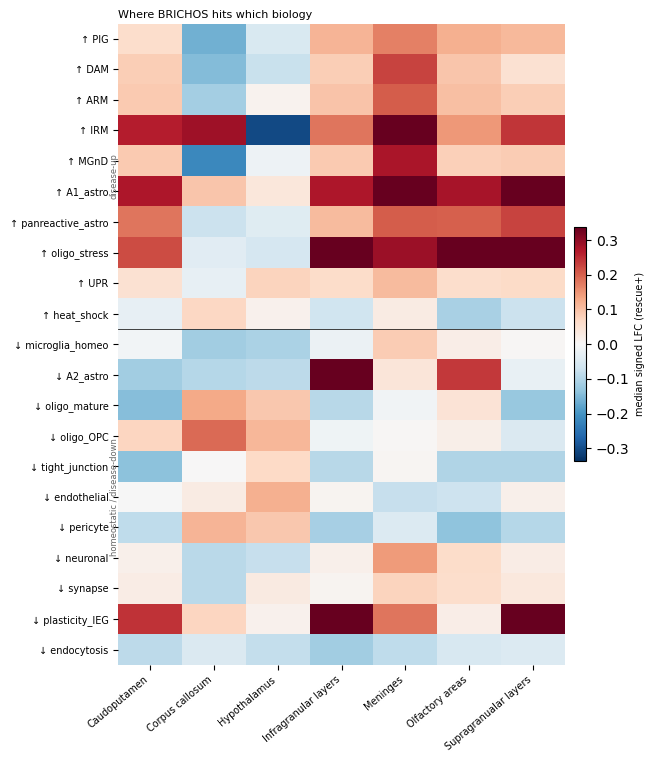

In [5]:
# Order signatures so disease-up programs sit on top, homeostatic
# (disease-down) below; label arrows indicate the prior used.
order_up = [s for s, d in SIGNATURE_DIRECTION.items()
            if d == 'up' and s in SIGNATURE_REGISTRY]
order_dn = [s for s, d in SIGNATURE_DIRECTION.items()
            if d == 'down' and s in SIGNATURE_REGISTRY]
ordered = order_up + order_dn

pivot = (broad_df.pivot(index='signature', columns='region',
                         values='median_signed')
         .reindex(ordered).fillna(0))
ylabels = [
    ('\u2191 ' if SIGNATURE_DIRECTION.get(s) == 'up' else '\u2193 ') + s
    for s in pivot.index
]

fig, ax = plt.subplots(figsize=(0.55 * pivot.shape[1] + 2.8,
                                 0.32 * pivot.shape[0] + 1.0))
vmax = max(0.3, np.nanpercentile(np.abs(pivot.values), 95))
im = ax.imshow(pivot.values, cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right',
                   fontsize=7)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(ylabels, fontsize=7)
# divider between disease-up and disease-down blocks
ax.axhline(len(order_up) - 0.5, color='#222', linewidth=0.6)
ax.text(-0.5, len(order_up) / 2 - 0.5, 'disease-up',
        rotation=90, ha='right', va='center', fontsize=6,
        color='#666')
ax.text(-0.5, len(order_up) + len(order_dn) / 2 - 0.5,
        'homeostatic / disease-down',
        rotation=90, ha='right', va='center', fontsize=6,
        color='#666')
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('median signed LFC (rescue+)', fontsize=7)
ax.set_title('Where BRICHOS hits which biology', loc='left',
             fontsize=8, pad=4)
fig.tight_layout()
fig.savefig(FIG / 'broader_signatures_heatmap.svg',
            bbox_inches='tight')
fig.savefig(FIG / 'broader_signatures_heatmap.png',
            bbox_inches='tight', dpi=200)
plt.show()


### 2. Per-region top BRI-vs-PBS DEGs OUTSIDE PIG

Discovery mode: which novel genes (not in PIG) are strongly modulated by BRICHOS? Each region gets a top-N by |LFC| with literature-set membership annotated.

In [ ]:
TOPN = 30
pig_set = set(PIG_CHEN2020)

def annotate_membership(gene):
    return ','.join(name for name, gs in SIGNATURE_REGISTRY.items()
                    if gene in gs)

discovery_tables = {}
for region, res in rescue_lfc.items():
    df = pd.DataFrame({'lfc': res.lfc, 'pvalue': res.pvalue,
                       'padj': res.padj}).copy()
    df = df[df.padj < 0.1]                  # adjust as desired
    df = df[~df.index.isin(pig_set)]        # PIG-orthogonal
    df['memberships'] = [annotate_membership(g) for g in df.index]
    df = df.reindex(df.lfc.abs().sort_values(ascending=False).index)
    discovery_tables[region] = df.head(TOPN)

# write per-region tables to a single multi-sheet TSV-like file
with open(TBL / 'discovery_top_DEGs_per_region.tsv', 'w') as f:
    for region, sub in discovery_tables.items():
        f.write(f'## {region}\n')
        sub.to_csv(f, sep='\t')
        f.write('\n')
print(f'wrote discovery_top_DEGs_per_region.tsv with '
      f'{len(discovery_tables)} regions')


In [ ]:
# Display top-15 for each region inline
for region, sub in discovery_tables.items():
    print(f'\n=== {region} ===')
    print(sub.head(15).round(3).to_string())


### 3. Pathway enrichment (optional)

Requires `gseapy` (`pip install gseapy`). For each rescue region ranks genes by signed LFC and runs GSEA prerank against MSigDB Hallmark + GO_BP. Skip if package missing.

In [ ]:
try:
    import gseapy
    have_gseapy = True
except ImportError:
    print('gseapy not installed — skipping enrichment')
    have_gseapy = False

if have_gseapy:
    enrich_results = {}
    for region, res in rescue_lfc.items():
        rnk = res.lfc.dropna().sort_values(ascending=False)
        try:
            pre = gseapy.prerank(
                rnk=rnk.reset_index().rename(
                    columns={'index':'gene', 'lfc':'lfc'}),
                gene_sets='GO_Biological_Process_2021',
                organism='mouse', no_plot=True,
                outdir=None, threads=4)
            enrich_results[region] = pre.res2d.head(20)
        except Exception as e:
            print(f'  {region}: {e}')
    for region, df in enrich_results.items():
        df.to_csv(TBL / f'gsea_{region.replace(" ", "_")}.tsv',
                  sep='\t', index=False)
        print(f'\n=== {region} top 5 ===')
        print(df[['Term', 'NES', 'NOM p-val']].head(5).to_string())
